# README

This notebook implements a **CycleGAN (Cycle-Consistent Generative Adversarial Network)** to remove artifacts from X-ray images and translate them into a clean, artifact-free version. Since there is no exact clean copy available for every artifact image (the data is unpaired), a CycleGAN is used instead of a paired translation model like Pix2Pix. This notebook is a **pilot run** on a small sample dataset to test the approach before scaling up.

---

## Project Methodology

**Phase I: Dataset Preparation**

---
1. Import the required libraries (**PyTorch**, **Torchvision**, **PIL**).
2. Unzip the pilot run dataset (pilot_run_dataset.zip) from Google Drive into the Colab runtime. The dataset has two folders: **artifacts** (domain A) and **clean** (domain B).
3. Build a custom Dataset class that loads images from the artifacts folder and the clean folder independently, since the two folders don't need to have the same number of images (unpaired data).
4. Apply **Resize (224x224)**, **Random Horizontal Flip**, **ToTensor** and **Normalize (mean 0.5, std 0.5)** as transforms, then load the dataset into a Dataloader with batch size 1.

**Phase II: Model Architecture**

---
1. Build a **Residual Block** (Conv, InstanceNorm, ReLU, Conv, InstanceNorm, with a skip connection), the core building block used inside the Generator.
2. Build a **ResNet-style Generator**: an initial 7x7 convolution block, 2 downsampling layers, 6 Residual Blocks, 2 upsampling layers, and a final 7x7 convolution with **Tanh** activation.
3. Build a **PatchGAN Discriminator** with 4 convolution layers. Instead of judging the whole image as real or fake at once, it classifies smaller patches of the image.
4. Create two Generators, **G_AB** (artifact to clean) and **G_BA** (clean to artifact), and two Discriminators, **D_A** and **D_B**, to complete the CycleGAN setup.

**Phase III: Training**

---
1. Define three loss functions: **Adversarial loss (MSE)**, **Cycle-Consistency loss (L1)** and **Identity loss (L1)**.
2. Set up **Adam** optimizers, one for both Generators together and one each for the two Discriminators (Learning Rate: 0.0002, Betas: 0.5, 0.999).
3. Train for **200 epochs**. In every batch, generate a fake clean image from a real artifact image, and a fake artifact image from a real clean image, using the two Generators.
4. Compute the Adversarial loss (how well each Generator fools its Discriminator), the Cycle-Consistency loss (translate the fake image back to its original domain and compare it with the real image), and the Identity loss (check that a Generator leaves an already-correct-domain image unchanged).
5. Combine the total Generator loss as **Adversarial loss + 10 x Cycle-Consistency loss + 5 x Identity loss**, then update both Generators together.
6. Update Discriminator A and Discriminator B separately, using real and generated images.
7. Print the Generator and Discriminator losses after every 100 batches to track training progress.
8. Save model checkpoints (**G_AB**, **G_BA**, **D_A**, **D_B**) and sample translated images after every epoch.
9. Zip the generated sample images folder for download once training is complete.

**Phase IV: Inference & Visualization**

---
1. Load a trained **G_AB** Generator checkpoint (epoch 149) for inference.
2. Build a function that resizes and normalizes a new image the same way as training, passes it through the Generator, and de-normalizes the output back to the original [0,1] pixel range.
3. Translate a sample artifact image into its clean version using **G_AB** and save the result.
4. Display the original artifact image and the translated clean image side by side to visually compare the result.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid
from PIL import Image
import os


In [ ]:
# Unzipping dataset
!unzip /content/drive/MyDrive/cycleGAN/Dataset/pilot_run_dataset.zip -d /content/

Archive:  /content/drive/MyDrive/cycleGAN/Dataset/pilot_run_dataset.zip
   creating: /content/pilot_run_dataset/
   creating: /content/pilot_run_dataset/artifacts/
 extracting: /content/pilot_run_dataset/artifacts/00000013_007.png  
 extracting: /content/pilot_run_dataset/artifacts/00000013_011.png  
  inflating: /content/pilot_run_dataset/artifacts/00000013_012.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_011.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_014.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_015.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_016.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_017.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_018.png  
  inflating: /content/pilot_run_dataset/artifacts/00000032_054.png  
  inflating: /content/pilot_run_dataset/artifacts/00000042_006.png  
  inflating: /content/pilot_run_dataset/artifacts/00000047_003.png  
  inflat

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, root_A, root_B, transform=None):
        self.transform = transform
        self.files_A = sorted(os.listdir(root_A))
        self.files_B = sorted(os.listdir(root_B))
        self.root_A = root_A
        self.root_B = root_B

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

    def __getitem__(self, idx):
        img_A = Image.open(os.path.join(self.root_A, self.files_A[idx % len(self.files_A)])).convert("RGB")
        img_B = Image.open(os.path.join(self.root_B, self.files_B[idx % len(self.files_B)])).convert("RGB")

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return {"A": img_A, "B": img_B}


# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224), Image.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Example usage
dataset = ImageDataset("/content/pilot_run_dataset/artifacts", "/content/pilot_run_dataset/clean", transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=2)


In [ ]:
# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features)
        )

    def forward(self, x):
        return x + self.block(x)

# Generator (ResNet style)
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, n_residual_blocks=6):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True)
        ]

        # Downsampling
        in_features, out_features = 64, 128
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features, out_features = out_features, out_features * 2

        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features, out_features = out_features, out_features // 2

        # Output layer
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, out_channels, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

# PatchGAN Discriminator
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        def block(in_filters, out_filters, normalize=True):
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 1, 4, padding=1)
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [ ]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("generated_images", exist_ok=True)

epochs = 200

for epoch in range(epochs):
    for i, batch in enumerate(dataloader):
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)

        # Train Generators
        optimizer_G.zero_grad()

        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)

        loss_GAN_AB = criterion_GAN(D_B(fake_B), torch.ones_like(D_B(fake_B)))
        loss_GAN_BA = criterion_GAN(D_A(fake_A), torch.ones_like(D_A(fake_A)))

        recov_A = G_BA(fake_B)
        recov_B = G_AB(fake_A)

        loss_cycle_A = criterion_cycle(recov_A, real_A)
        loss_cycle_B = criterion_cycle(recov_B, real_B)

        loss_identity_A = criterion_identity(G_BA(real_A), real_A)
        loss_identity_B = criterion_identity(G_AB(real_B), real_B)

        loss_G = loss_GAN_AB + loss_GAN_BA + 10.0 * (loss_cycle_A + loss_cycle_B) + 5.0 * (loss_identity_A + loss_identity_B)
        loss_G.backward()
        optimizer_G.step()

        # Train Discriminator A
        optimizer_D_A.zero_grad()
        loss_D_A = (criterion_GAN(D_A(real_A), torch.ones_like(D_A(real_A))) +
                    criterion_GAN(D_A(fake_A.detach()), torch.zeros_like(D_A(fake_A)))) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()

        # Train Discriminator B
        optimizer_D_B.zero_grad()
        loss_D_B = (criterion_GAN(D_B(real_B), torch.ones_like(D_B(real_B))) +
                    criterion_GAN(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B)))) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()

        if i % 100 == 0:
            print(f"Epoch [{epoch}/{epochs}] Batch {i} | Loss_G: {loss_G.item():.4f} | Loss_DA: {loss_D_A.item():.4f} | Loss_DB: {loss_D_B.item():.4f}")

    # Save checkpoints
    torch.save(G_AB.state_dict(), f"checkpoints/G_AB_epoch{epoch}.pth")
    torch.save(G_BA.state_dict(), f"checkpoints/G_BA_epoch{epoch}.pth")
    torch.save(D_A.state_dict(), f"checkpoints/D_A_epoch{epoch}.pth")
    torch.save(D_B.state_dict(), f"checkpoints/D_B_epoch{epoch}.pth")

    # Save sample images
    save_image(make_grid(fake_B[:4], nrow=2, normalize=True), f"generated_images/fakeB_epoch{epoch}.png")
    save_image(make_grid(fake_A[:4], nrow=2, normalize=True), f"generated_images/fakeA_epoch{epoch}.png")


Epoch [0/200] Batch 0 | Loss_G: 3.0782 | Loss_DA: 0.2912 | Loss_DB: 0.1085
Epoch [1/200] Batch 0 | Loss_G: 2.3853 | Loss_DA: 0.2238 | Loss_DB: 0.1804
Epoch [2/200] Batch 0 | Loss_G: 2.3507 | Loss_DA: 0.2603 | Loss_DB: 0.0436
Epoch [3/200] Batch 0 | Loss_G: 2.8633 | Loss_DA: 0.1816 | Loss_DB: 0.0368
Epoch [4/200] Batch 0 | Loss_G: 2.9458 | Loss_DA: 0.2150 | Loss_DB: 0.0100
Epoch [5/200] Batch 0 | Loss_G: 3.3384 | Loss_DA: 0.1515 | Loss_DB: 0.0239
Epoch [6/200] Batch 0 | Loss_G: 3.0311 | Loss_DA: 0.1695 | Loss_DB: 0.0075
Epoch [7/200] Batch 0 | Loss_G: 3.3406 | Loss_DA: 0.1821 | Loss_DB: 0.0173
Epoch [8/200] Batch 0 | Loss_G: 2.9113 | Loss_DA: 0.2604 | Loss_DB: 0.0065
Epoch [9/200] Batch 0 | Loss_G: 3.0243 | Loss_DA: 0.1959 | Loss_DB: 0.0269
Epoch [10/200] Batch 0 | Loss_G: 2.9386 | Loss_DA: 0.1710 | Loss_DB: 0.0028
Epoch [11/200] Batch 0 | Loss_G: 3.3406 | Loss_DA: 0.2388 | Loss_DB: 0.0095
Epoch [12/200] Batch 0 | Loss_G: 2.4636 | Loss_DA: 0.2991 | Loss_DB: 0.0113
Epoch [13/200] Batch 0

In [ ]:
!zip -r /content/generated_images.zip /content/generated_images

  adding: content/generated_images/ (stored 0%)
  adding: content/generated_images/fakeB_epoch2.png (stored 0%)
  adding: content/generated_images/fakeB_epoch15.png (stored 0%)
  adding: content/generated_images/fakeA_epoch38.png (stored 0%)
  adding: content/generated_images/fakeB_epoch43.png (stored 0%)
  adding: content/generated_images/fakeB_epoch21.png (stored 0%)
  adding: content/generated_images/fakeA_epoch9.png (stored 0%)
  adding: content/generated_images/fakeA_epoch40.png (stored 0%)
  adding: content/generated_images/fakeA_epoch26.png (stored 0%)
  adding: content/generated_images/fakeB_epoch23.png (stored 0%)
  adding: content/generated_images/fakeB_epoch44.png (stored 0%)
  adding: content/generated_images/fakeB_epoch19.png (stored 0%)
  adding: content/generated_images/fakeA_epoch44.png (stored 0%)
  adding: content/generated_images/fakeB_epoch27.png (stored 0%)
  adding: content/generated_images/fakeA_epoch5.png (stored 0%)
  adding: content/generated_images/fakeB_epoc

In [ ]:
def load_model(path, model):
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model

# Load trained generator
G_AB = load_model("/content/checkpoints/G_AB_epoch149.pth", Generator().to(device))

# Inference function
def translate_image(image_path, generator, save_path="output.png"):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
    ])
    img = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        fake_img = generator(img)
    save_image(fake_img * 0.5 + 0.5, save_path)  # De-normalize to [0,1]

# Example
translate_image("/content/00000368_002.png", G_AB, "translated_output.png")


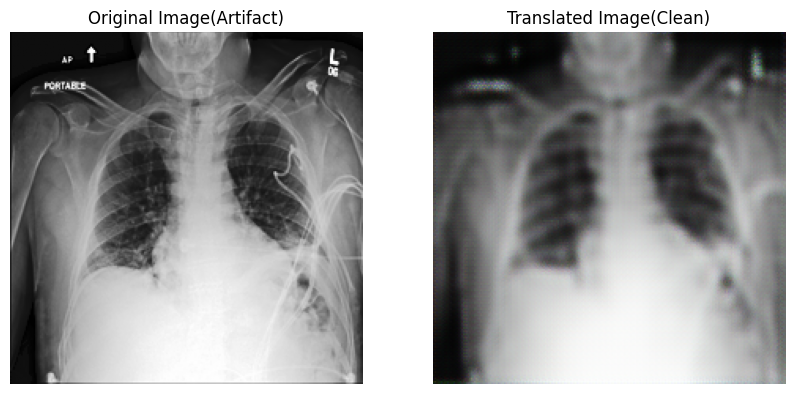

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the images
original_image = mpimg.imread("/content/00000368_002.png")
translated_image = mpimg.imread("translated_output.png")

# Display the images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image(Artifact)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(translated_image, cmap='gray')
plt.title("Translated Image(Clean)")
plt.axis("off")

plt.show()